# Student Dropout Prediction

In [ ]:
#import pandas
import pandas as pd

#import numpy
import numpy as np

#import matplotlib
import matplotlib.pyplot as plt

#import seaborn
import seaborn as sns

In [ ]:
# read the data file we have in the folder
df = pd.read_csv('students_dropout_academic_success.csv')

Once your Google Drive is mounted, you can copy the file to your Colab environment or directly access it. To copy the file, you can use the following command in a new code cell:

```python
!cp '/content/drive/MyDrive/DM CIPAT/students_dropout_academic_success.csv' './students_dropout_academic_success.csv'
```

After copying, you can then load the CSV into a pandas DataFrame:

```python
import pandas as pd
df = pd.read_csv('students_dropout_academic_success.csv')
display(df.head())
```

Let me know if you'd like me to generate these code cells for you, or if you prefer to run them manually after mounting the drive.

In [ ]:
# show first five observation of the data
df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
# Show the last five observation of the data
df.tail()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate
4423,1,10,1,9773,1,1,152.0,22,38,37,...,0,6,6,6,13.000000,0,12.7,3.7,-1.70,Graduate


In [ ]:
df.shape

(4424, 37)

Interpretation

- we have 4424 Observation (rows)
- we have 37 attributes (columns)

# DATA PREPROCESSING

In [ ]:
# Show the basic info of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

Interpretation
 - No null Values
 - No. of Float values = 7
 - No. of Integer values = 29
 - No. of Catgorical/Object values = 1 (i.e Target)

In [ ]:
# Justify the basic statistics of the data
df.describe()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


Outliers exist

In [ ]:
df.isnull().sum()

,0
Marital Status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


No Null Values

Duplication

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

Separating Target Attribute

In [ ]:
y = df['target']  # Target variable
X = df.drop('target', axis=1)   # All independent variables

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4424, 36)
y shape: (4424,)


In [ ]:
# Check target distribution
print("\nTarget distribution:")
target_counts = df['target'].value_counts()
print(target_counts)


Target distribution:
target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [ ]:
print(f"Dropout rate: {target_counts['Dropout'] / len(df) * 100:.2f}%")
print(f"Graduation rate: {target_counts['Graduate'] / len(df) * 100:.2f}%")
print(f"Still enrolled: {target_counts['Enrolled'] / len(df) * 100:.2f}%")

Dropout rate: 32.12%
Graduation rate: 49.93%
Still enrolled: 17.95%


In [ ]:
cols = X.columns
print (cols)


Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

Treating Outliers

In [ ]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_pct = outliers_count / len(df) * 100
    print(f"{col}: {outliers_count} outliers ({outlier_pct:.2f}%)")

Marital Status: 505 outliers (11.42%)
Application mode: 0 outliers (0.00%)
Application order: 541 outliers (12.23%)
Course: 442 outliers (9.99%)
Daytime/evening attendance: 483 outliers (10.92%)
Previous qualification: 707 outliers (15.98%)
Previous qualification (grade): 179 outliers (4.05%)
Nacionality: 110 outliers (2.49%)
Mother's qualification: 0 outliers (0.00%)
Father's qualification: 0 outliers (0.00%)
Mother's occupation: 182 outliers (4.11%)
Father's occupation: 177 outliers (4.00%)
Admission grade: 86 outliers (1.94%)
Displaced: 0 outliers (0.00%)
Educational special needs: 51 outliers (1.15%)
Debtor: 503 outliers (11.37%)
Tuition fees up to date: 528 outliers (11.93%)
Gender: 0 outliers (0.00%)
Scholarship holder: 1099 outliers (24.84%)
Age at enrollment: 441 outliers (9.97%)
International: 110 outliers (2.49%)
Curricular units 1st sem (credited): 577 outliers (13.04%)
Curricular units 1st sem (enrolled): 424 outliers (9.58%)
Curricular units 1st sem (evaluations): 158 outl

In [ ]:
# Cap outliers for key columns
print("Capping outliers for key columns...")
for col in cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = max(Q1 - 1.5 * IQR, 0)  # Don't go below 0 for grades
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers instead of removing them
    X[col] = X[col].clip(lower_bound, upper_bound)

    print(f"Column {col} capped between {lower_bound:.2f} and {upper_bound:.2f}")

Capping outliers for key columns...
Column Marital Status capped between 1.00 and 1.00
Column Application mode capped between 0.00 and 96.00
Column Application order capped between 0.00 and 3.50
Column Course capped between 8378.50 and 10262.50
Column Daytime/evening attendance capped between 1.00 and 1.00
Column Previous qualification capped between 1.00 and 1.00
Column Previous qualification (grade) capped between 102.50 and 162.50
Column Nacionality capped between 1.00 and 1.00
Column Mother's qualification capped between 0.00 and 89.50
Column Father's qualification capped between 0.00 and 88.00
Column Mother's occupation capped between 0.00 and 16.50
Column Father's occupation capped between 0.00 and 16.50
Column Admission grade capped between 92.55 and 160.15
Column Displaced capped between 0.00 and 2.50
Column Educational special needs capped between 0.00 and 0.00
Column Debtor capped between 0.00 and 0.00
Column Tuition fees up to date capped between 1.00 and 1.00
Column Gender 

# DATA TRANSFORMATION

Encoding Categorical Variables

In [ ]:
# perform encoding in (one hot encoding)
# Y = pd.get_dummies(y)
y=y.map({'Graduate':2,'Enrolled':1,'Dropout':0})

In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
scale = ss.fit_transform(X)

# Feature Engineering

In [ ]:
# Academic performance indicators
X['overall_grade_avg'] = (X['Curricular units 1st sem (grade)'] +
                                    X['Curricular units 2nd sem (grade)']) / 2

X['grade_change'] = X['Curricular units 2nd sem (grade)'] - \
                              X['Curricular units 1st sem (grade)']

In [ ]:
# Social and environmental indicators
X['parents_edu_level'] = (X['Mother\'s qualification'] + X['Father\'s qualification']) / 2
X['financial_stability'] = np.where(
    (X['Debtor'] == 0) & (X['Tuition fees up to date'] == 1), 1, 0)

# Economic context index
X['economic_context'] = X['GDP'] - (X['Unemployment rate'] * X['Inflation rate'] / 100)


In [ ]:
X['total_approved_units'] = (
    X['Curricular units 1st sem (approved)'] +
    X['Curricular units 2nd sem (approved)']
)

In [ ]:
X['financial_risk'] = X['Debtor'] + (1 - X['Tuition fees up to date'])

In [ ]:
X.columns

Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [ ]:
X.shape

(4424, 43)

# DATA VISUALIZATIONaa
EDA(Exploratory Data Analysis)

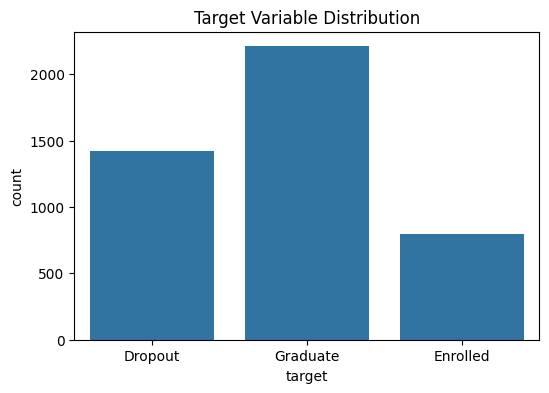

target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Target Variable Distribution")
plt.show()

print(df['target'].value_counts(normalize=True)*100)

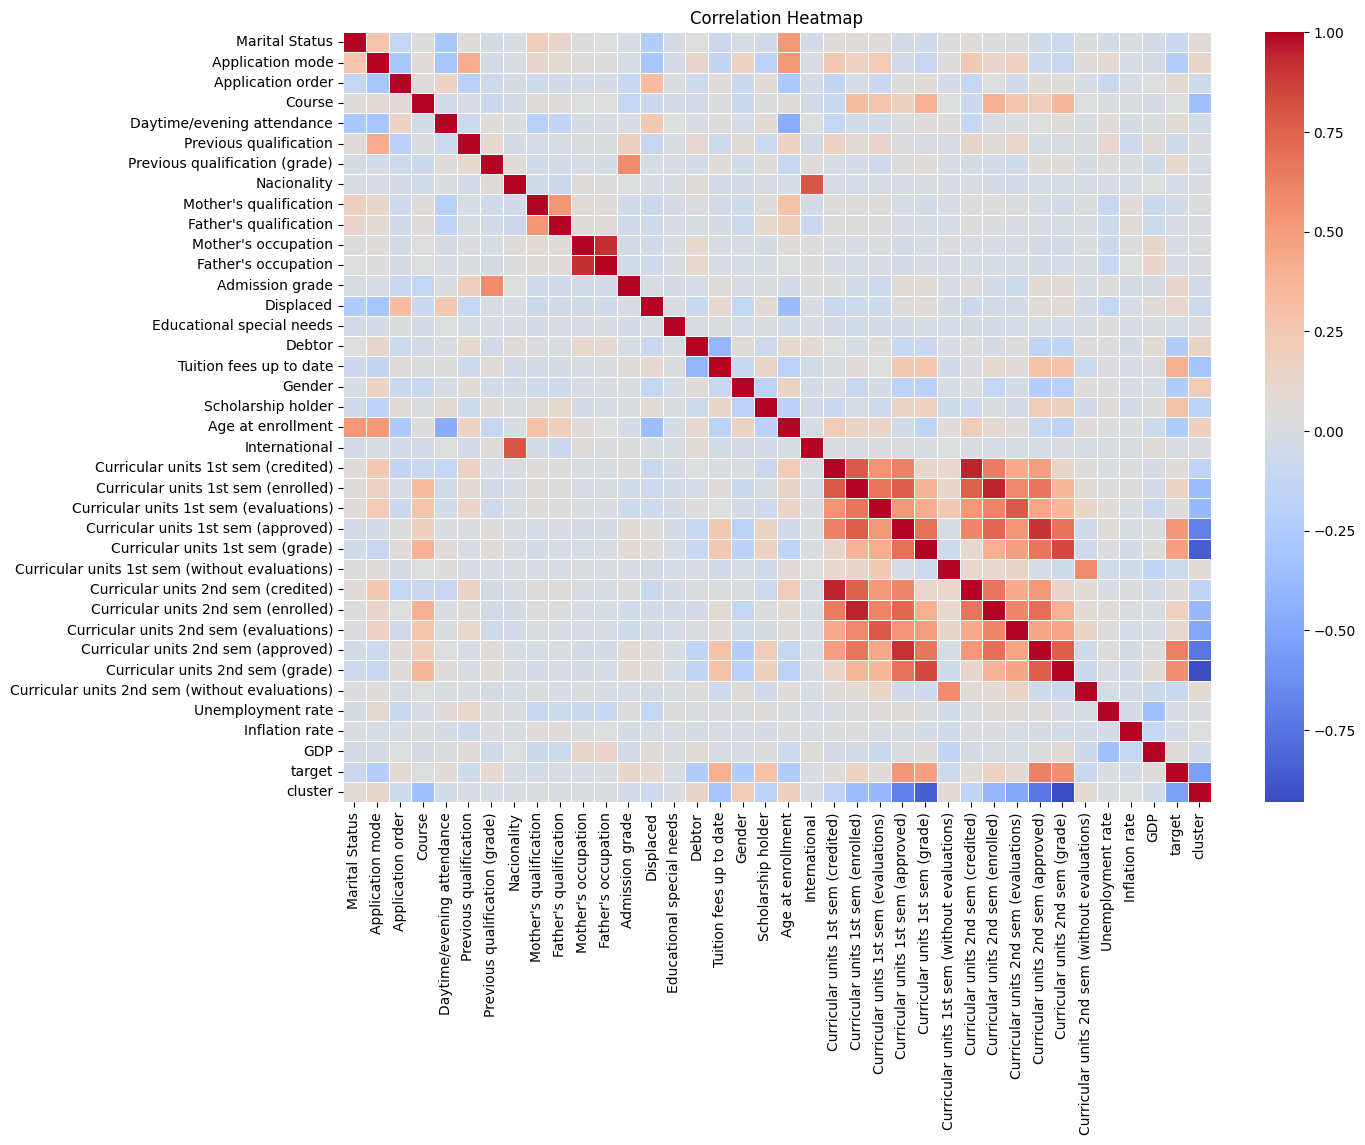

In [ ]:
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

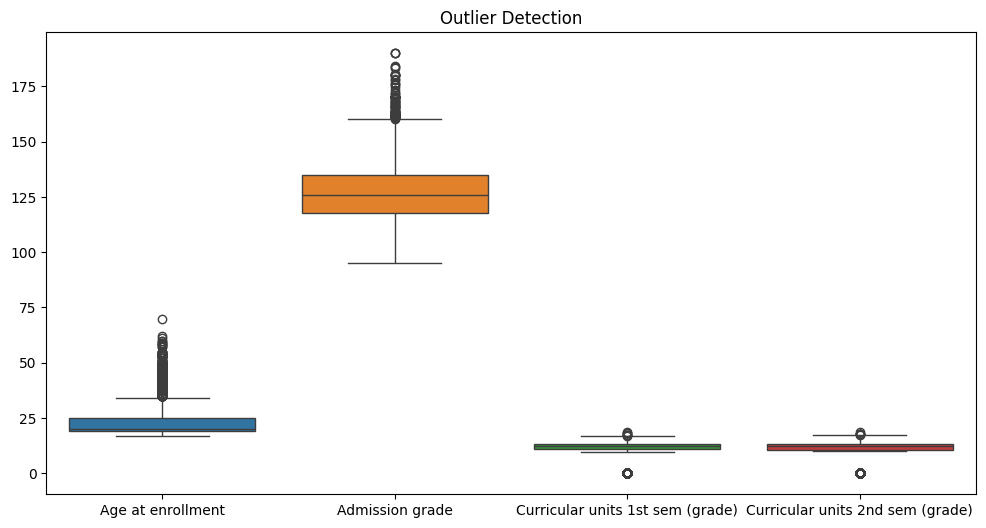

In [ ]:
cols = [
    'Age at enrollment',
    'Admission grade',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]

plt.figure(figsize=(12,6))
sns.boxplot(data=df[cols])
plt.title("Outlier Detection")
plt.show()

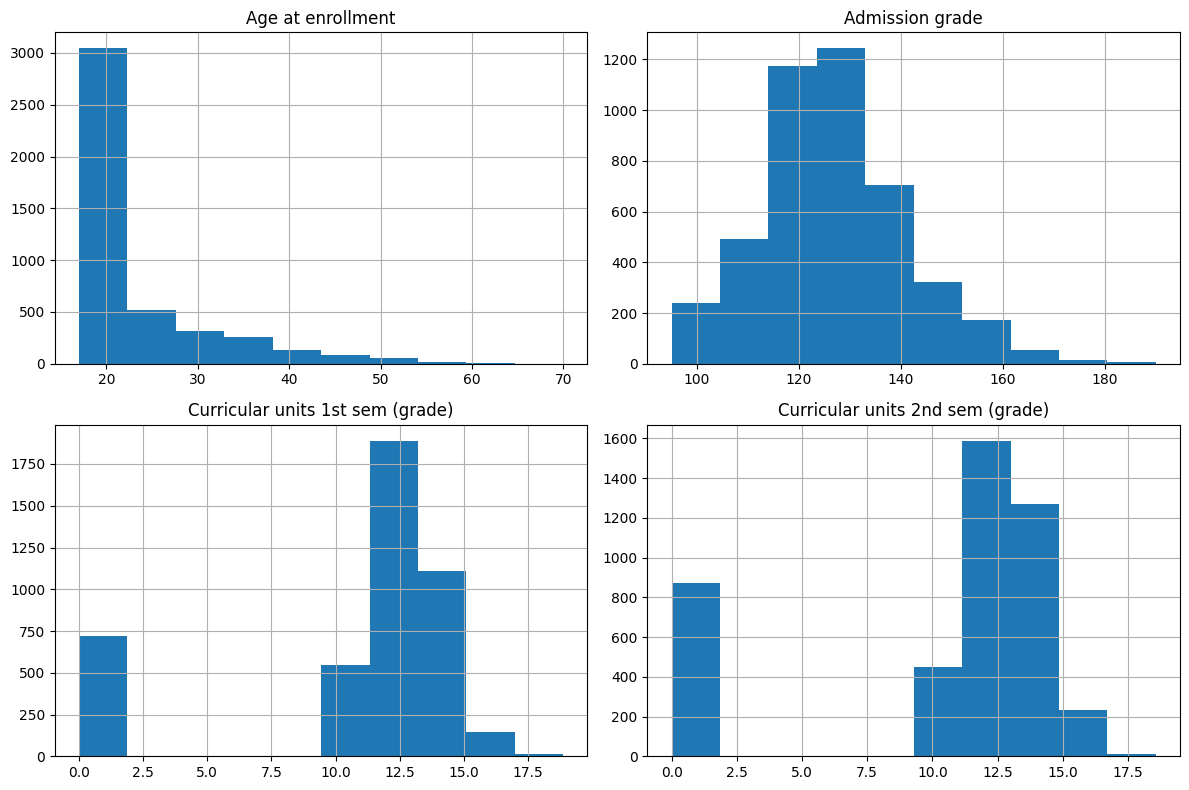

In [ ]:
df[cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

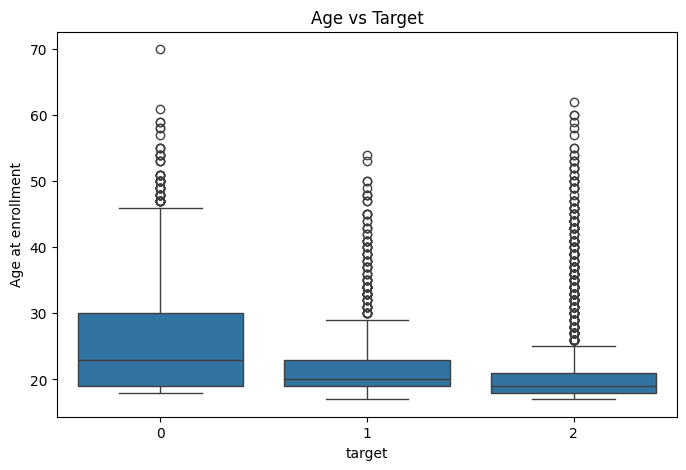

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['target'], y=df['Age at enrollment'])
plt.title("Age vs Target")
plt.show()

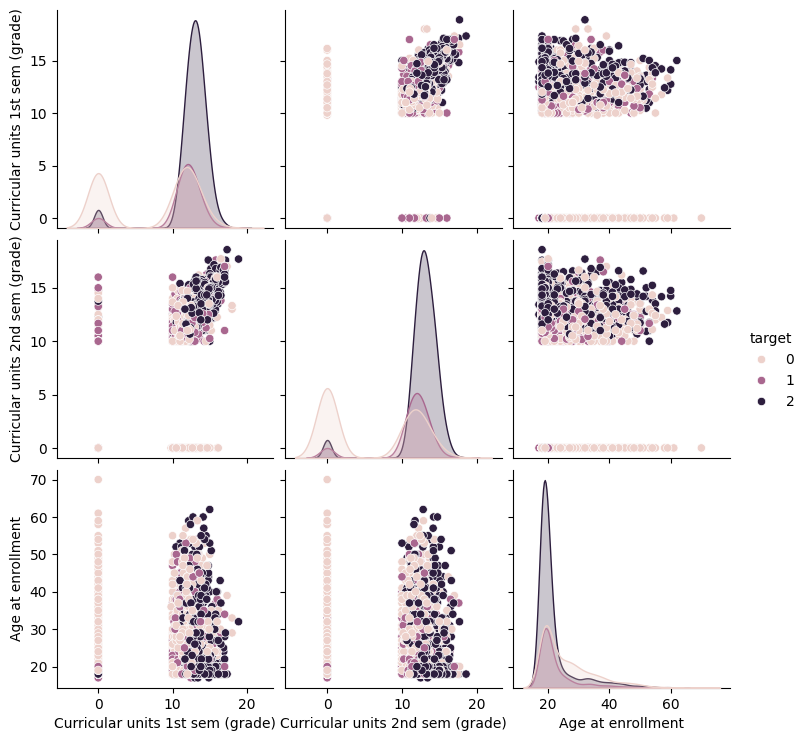

In [ ]:
pair_cols = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Age at enrollment',
    'target'
]

sns.pairplot(df[pair_cols], hue='target')
plt.show()

In [ ]:
X.columns

Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [ ]:
df_temp = df.copy()

# Convert target to numeric using categorical codes for robustness
df_temp['target'] = df_temp['target'].astype('category').cat.codes

# Debug print to check the state of the target column after mapping
print("df_temp['target'] value counts after mapping:")
print(df_temp['target'].value_counts())
print("df_temp['target'] dtype after mapping:", df_temp['target'].dtype)

corr = df_temp.corr(numeric_only=True)
target_corr = corr['target'].sort_values(ascending=False)

print(target_corr)

df_temp['target'] value counts after mapping:
target
2    2209
0    1421
1     794
Name: count, dtype: int64
df_temp['target'] dtype after mapping: int8
target                                            1.000000
Curricular units 2nd sem (approved)               0.624157
Curricular units 2nd sem (grade)                  0.566827
Curricular units 1st sem (approved)               0.529123
Curricular units 1st sem (grade)                  0.485207
Tuition fees up to date                           0.409827
Scholarship holder                                0.297595
Curricular units 2nd sem (enrolled)               0.175847
Curricular units 1st sem (enrolled)               0.155974
Admission grade                                   0.120889
Displaced                                         0.113986
Previous qualification (grade)                    0.103764
Curricular units 2nd sem (evaluations)            0.092721
Application order                                 0.089791
Daytime/evening atten

#Prepare the data for machine learning

scaling Data

In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
cols = X.columns
X = ss.fit_transform(X)
X = pd.DataFrame(X, columns=cols)
pd.DataFrame(X)

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Unemployment rate,Inflation rate,GDP,overall_grade_avg,grade_change,parents_edu_level,financial_stability,economic_context,total_approved_units,financial_risk
0,0.0,-0.095470,2.102099,-2.191159,0.0,0.0,-0.834072,0.0,-0.036018,-0.669778,...,-0.287638,0.039995,0.695440,-1.938921,-0.175760,-0.399757,0.0,0.663727,-1.633746,0.0
1,0.0,-0.209869,-0.619176,-0.099999,0.0,0.0,2.183947,0.0,-1.189759,-1.256427,...,0.876222,-1.099440,-0.172134,0.899727,-0.048938,-1.395714,0.0,-0.030214,0.546992,0.0
2,0.0,-1.010660,2.102099,-0.539489,0.0,0.0,-0.834072,0.0,1.117723,0.959802,...,-0.287638,0.039995,0.695440,-1.938921,-0.175760,1.186397,0.0,0.663727,-1.633746,0.0
3,0.0,-0.095470,0.469334,1.139649,0.0,0.0,-0.834072,0.0,1.181819,0.959802,...,-0.813253,-1.099440,-0.893590,0.510103,-0.508963,1.223284,0.0,-0.716511,0.365264,0.0
4,0.0,1.162916,-0.619176,-2.191159,0.0,0.0,-2.382792,0.0,1.117723,1.024985,...,0.876222,-1.099440,-0.172134,0.405127,0.612742,1.223284,0.0,-0.030214,0.365264,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,0.0,-1.010660,2.102099,1.139649,0.0,0.0,-0.595807,0.0,-1.189759,-1.386793,...,1.476924,1.179431,-0.893590,0.602967,-0.445946,-1.469489,0.0,-1.093540,0.183536,0.0
4420,0.0,-1.010660,0.469334,1.139649,0.0,0.0,-0.992915,0.0,-1.189759,-1.386793,...,-0.175007,-0.611111,0.951146,-0.089472,-0.490058,-1.469489,0.0,0.980467,-0.179921,0.0
4421,0.0,-1.010660,-0.619176,0.487580,0.0,0.0,1.707418,0.0,1.117723,0.959802,...,0.876222,-1.099440,-0.172134,1.057822,-0.763001,1.186397,0.0,-0.030214,-0.179921,0.0
4422,0.0,-1.010660,-0.619176,-0.355572,0.0,0.0,2.382501,0.0,1.117723,0.959802,...,-0.813253,-1.099440,-0.893590,0.504047,-1.019402,1.186397,0.0,-0.716511,0.183536,0.0


Splitting the data into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

SVM (Support Vector Machine)

In [ ]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("SVM:\n", classification_report(y_test, y_pred_svm))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))
print("XGBoost:\n", classification_report(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, knn_pred))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.78      0.72      0.75       316
           1       0.46      0.25      0.32       151
           2       0.73      0.90      0.81       418

    accuracy                           0.72       885
   macro avg       0.66      0.62      0.63       885
weighted avg       0.70      0.72      0.70       885

SVM:
               precision    recall  f1-score   support

           0       0.86      0.70      0.77       316
           1       0.53      0.32      0.40       151
           2       0.74      0.95      0.83       418

    accuracy                           0.75       885
   macro avg       0.71      0.66      0.67       885
weighted avg       0.75      0.75      0.74       885

Random Forest:
               precision    recall  f1-score   support

           0       0.80      0.69      0.74       316
           1       0.48      0.25      0.33       151
           2       0.73      0.

In [ ]:
from sklearn.metrics import accuracy_score

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

LR Accuracy: 0.7242937853107345
SVM Accuracy: 0.7536723163841808
RF Accuracy: 0.7310734463276836
XGB Accuracy: 0.7310734463276836
KNN Accuracy: 0.6949152542372882


In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost','KNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, knn_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.724294
1                  SVM  0.753672
2        Random Forest  0.731073
3              XGBoost  0.731073
4                  KNN  0.694915


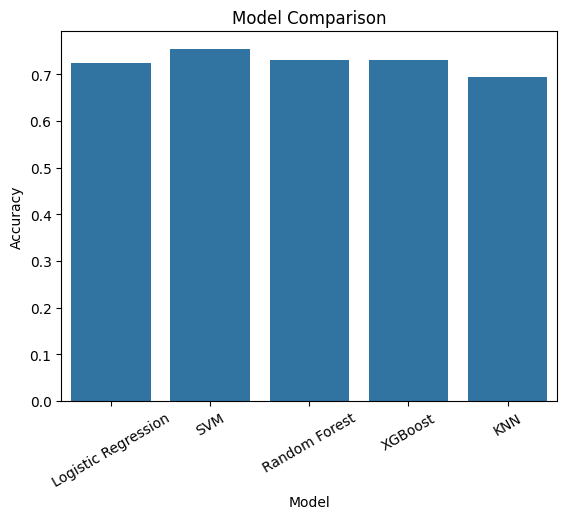

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Model', y='Accuracy', data=results)
plt.xticks(rotation=30)
plt.title("Model Comparison")
plt.show()

As per our problem , False Negative are more costly then False Postive. Hence we will consider Recall and f1-score as main performance parameter
To Conclude, XGBoost is the selected Baseline model

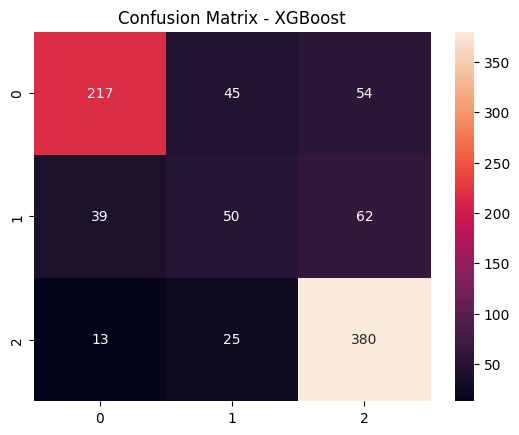

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - XGBoost")
plt.show()

#Hyper parameter tunning using cross validation

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
}

xgb = XGBClassifier()

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',   # important for multi-class
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200]},
             scoring='f1_macro')

In [ ]:
best_xgb = grid.best_estimator_

In [ ]:
y_pred_xgb = best_xgb.predict(X_test)

In [ ]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.80      0.72      0.76       316
           1       0.47      0.29      0.36       151
           2       0.76      0.92      0.83       418

    accuracy                           0.74       885
   macro avg       0.68      0.64      0.65       885
weighted avg       0.72      0.74      0.72       885



In [ ]:
pip install shap

In [ ]:
# import shap

# explainer = shap.Explainer(xgb)
# shap_values = explainer(X_test)

In [ ]:
# shap.summary_plot(shap_values, X_test)

In [ ]:
# shap.plots.waterfall(shap_values[0,0])


Clustering

In [ ]:
features = [
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Tuition fees up to date',
    'Debtor'
]

X_cluster = df[features]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

In [ ]:
print(df['cluster'].value_counts())

cluster
0    3255
2     848
1     321
Name: count, dtype: int64


In [ ]:
df.groupby('cluster')[features].mean()

,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (grade),Tuition fees up to date,Debtor
cluster,,,,,,
0,5.859908,5.674040,12.790900,12.777027,1.000000,0.061137
1,4.436137,3.370717,12.124778,9.987605,0.009346,0.504673
2,0.382075,0.086085,1.826132,0.546210,0.752358,0.167453


High Risk
- Low grades
- Low approved units
- High debtor

Medium Risk
- Medium performance

Low Risk
- High grades
- High approvals
- No debt

In [ ]:
df['risk_level'] = df['cluster'].map({
    0: 'Low Risk',
    1: 'Medium Risk',
    2: 'High Risk'
})

<Axes: xlabel='Curricular units 1st sem (grade)', ylabel='Curricular units 2nd sem (grade)'>

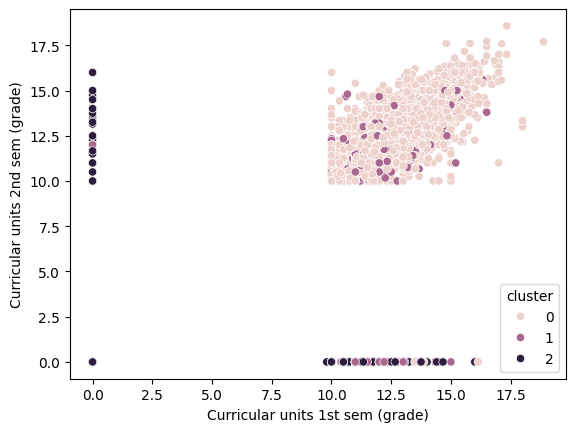

In [ ]:
import seaborn as sns

sns.scatterplot(
    x=df['Curricular units 1st sem (grade)'],
    y=df['Curricular units 2nd sem (grade)'],
    hue=df['cluster']
)

In [ ]:
features = [
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Tuition fees up to date',
    'Debtor',
    'Scholarship holder',
    'Age at enrollment'
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(df[features])

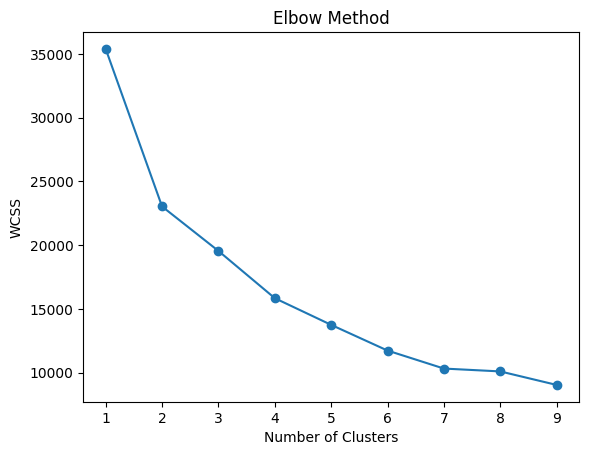

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    print(f"k={k}, Silhouette Score={score}")

k=2, Silhouette Score=0.45069235876382524
k=3, Silhouette Score=0.44516884291078684
k=4, Silhouette Score=0.38451235216099194
k=5, Silhouette Score=0.4030577598270885


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

In [ ]:
df['risk_level'] = df['cluster'].map({
    0: 'High Risk',
    1: 'Medium Risk',
    2: 'Low Risk'
})

In [ ]:
cluster_analysis = df.groupby('cluster')[features].mean()
print(cluster_analysis)

         Curricular units 1st sem (approved)  \
cluster                                        
0                                   5.814878   
1                                   0.537137   

         Curricular units 2nd sem (approved)  \
cluster                                        
0                                   5.579113   
1                                   0.134553   

         Curricular units 1st sem (grade)  Curricular units 2nd sem (grade)  \
cluster                                                                       
0                               12.765033                         12.730007   
1                                2.649304                          0.825680   

         Tuition fees up to date    Debtor  Scholarship holder  \
cluster                                                          
0                       0.932189  0.090415            0.288126   
1                       0.686760  0.201292            0.099031   

         Age at enrollment  
clu

In [ ]:
pd.crosstab(df['cluster'], df['target'])

target,0,1,2
cluster,,,
0,655,708,2132
1,766,86,77


<Axes: >

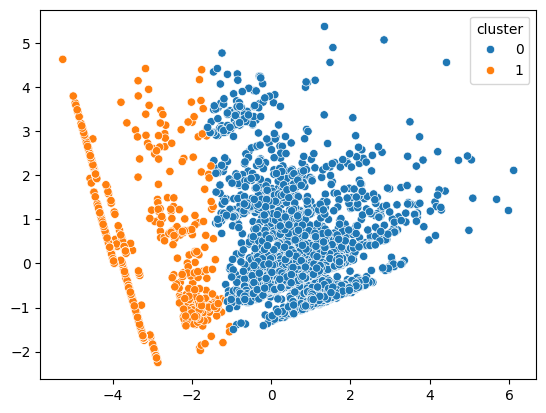

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

import seaborn as sns

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['cluster'])

In [ ]:
df.columns

Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [ ]:
pd.crosstab(df['cluster'], df['target'])


target,0,1,2
cluster,,,
0,655,708,2132
1,766,86,77


In [ ]:
drop_cols = ['target', 'cluster', 'risk_level', 'grade_category', 'approved_category']
X_cluster = df.drop(columns=drop_cols)

KeyError: "['grade_category', 'approved_category'] not found in axis"

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [ ]:
from sklearn.cluster import Birch
from sklearn.metrics import silhouette_score

thresholds = [0.2, 0.3, 0.5, 0.7, 1.0]

for t in thresholds:
    model = Birch(threshold=t, n_clusters=3)
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    print(f"Threshold={t}, Silhouette Score={score}")

In [ ]:
for k in range(2, 6):
    model = Birch(threshold=0.7, n_clusters=k)
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, Score={score}")

In [ ]:
from sklearn.cluster import Birch

birch_model = Birch(threshold=0.7, n_clusters=2)
df['cluster'] = birch_model.fit_predict(X_scaled)

In [ ]:
import numpy as np
print(np.bincount(df['cluster']))

In [ ]:
import pandas as pd
pd.crosstab(df['cluster'], df['target'])

In [ ]:
pd.crosstab(df['cluster'], df['target'], normalize='index') * 100

In [ ]:
df.groupby('cluster').mean(numeric_only=True)

In [ ]:
pd.crosstab(df['cluster'], df['risk_level'])

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='cluster', hue='target', data=df)
plt.show()

In [ ]:
df['cluster_label'] = df['cluster'].map({
    0: "Low Risk Students",
    1: "High Risk Students"
})

In [ ]:
pip install shap

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
shap_values = explainer(X_test)
shap.plots.waterfall(shap_values[0, :, 0])